# AI Court Bill Impact Analyzer - Colab Prototype

**Student/Author:** Claire Yuan

**Advisor:** Dr. Qingyang Xiao

**Technology:** Python, scikit-learn, PyTorch, document text extraction, uncertainty calibration, and a constrained reinforcement-learning demonstration

----

## Project purpose

This notebook demonstrates a research prototype that:

1. accepts a court-issued notice, citation, fine, or bill as text, PDF, or image;
2. extracts and validates non-sensitive case features;
3. trains classical machine-learning models on labeled historical outcomes;
4. trains a multi0task deep neural network in PyTorch;
5. estimates likely consequence ranges with uncertainty;
6. generates a plain-language impact
7. uses reinforcement learning to improve report presentation, but never to decide legal consequecnes.

## Why the output uses ranges instrea of fixed claims

A ticket does not have one universal insurance effect. For example, state's insrauce regulator explains that insureres may consider recent traffic violations and that premium calculations depend on multiple risk factors. Credit reports generally contain borrowing or payment histroy, collections, and certain public records. Therefore, this prototype does not translate a ticket directly into a fixed credit-score point loss. It separately flags possible nonpayment or collection escalation risk.

## Notebook roadmap

| Stage | What happends |
| --- | --- |
| 1 | Install and import packages and set reproducibility controls |
| 2 | Draw the system architecture |
| 3 | Define a privacy-preserving labeled-data schema |
| 4 | Generate synthetic training, calibration, and testing data |
| 5 | Explore the data and check for prohibited attributes |
| 6 | Train scikit-learn regression and classification models |
| 7 | Evaluate accuracy, calibration, and intepretability |
| 8 | Train a PyTorch multi-task neural network |
| 9 | Dmonstrate constrained reinforcement learning for report layout |
| 10 | Upload and extract a new court document or use a demo notice |
| 11 | Parse features, predict calibrated ranges, and generate a report |
| 12 | Save reusable model artifacts and review deployment controls |

In [1]:
# Colab setup. The core ML packages are normally preinstalled in Google Colab.
# OCR-related packages are installed only when running inside Colab.
import os, sys, subprocess, importlib.util

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q',
         'pypdf', 'pytesseract', 'pdf2image'],
        check=True
    )
    # Tesseract handles scanned images; Poppler converts scanned PDF pages to images.
    subprocess.run(
        'apt-get -qq update && apt-get -qq install -y tesseract-ocr poppler-utils >/dev/null',
        shell=True,
        check=True
    )
    print('Colab OCR dependencies installed.')
else:
    print('Local runtime detected. Core notebook can run without OCR packages.')

Colab OCR dependencies installed.


In [2]:
# Imports and reproducibility
import json
import math
import random
import re
import warnings
from dataclasses import dataclass, asdict
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import sklearn
import torch
import torch.nn as nn
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Python: {sys.version.split()[0]}')
print(f'pandas: {pd.__version__}')
print(f'scikit-learn: {sklearn.__version__}')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {DEVICE}')

Python: 3.13.15
pandas: 2.2.3
scikit-learn: 1.6.1
PyTorch: 2.11.0+cpu
Device: cpu


## 1. Architecture and safety boundary

The predictive layer estimates labeled historical outcomes. A separate reporting layer converts estimates into an understandable report. The system never changes an official disposition and never recommends guilt, sentencing, or judicial action.

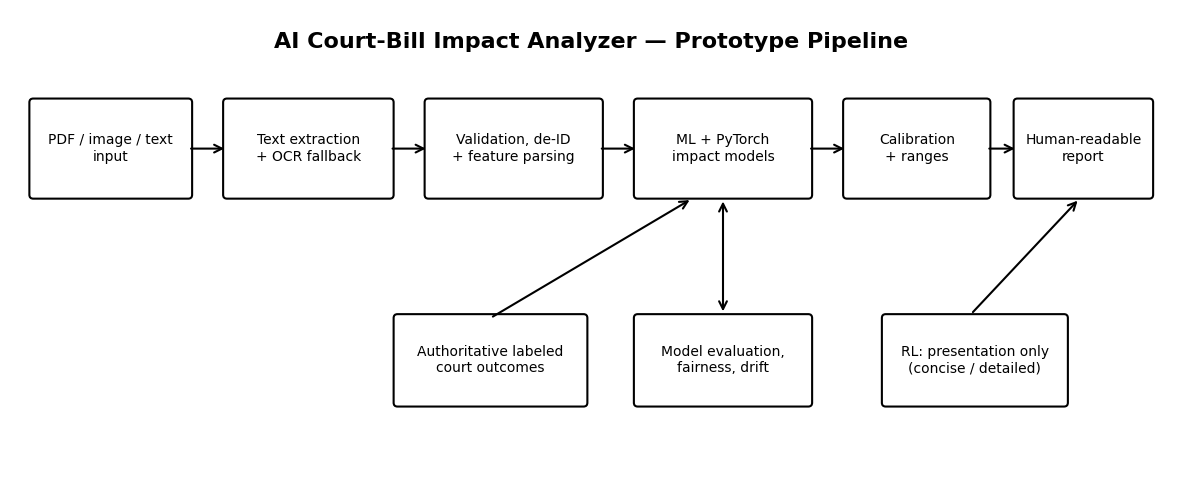

In [3]:
# Visual architecture diagram
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(15, 6))
ax.set_xlim(0, 15)
ax.set_ylim(0, 6)
ax.axis('off')

boxes = [
    (0.3, 3.6, 2.0, 1.2, 'PDF / image / text\ninput'),
    (2.8, 3.6, 2.1, 1.2, 'Text extraction\n+ OCR fallback'),
    (5.4, 3.6, 2.2, 1.2, 'Validation, de-ID\n+ feature parsing'),
    (8.1, 3.6, 2.2, 1.2, 'ML + PyTorch\nimpact models'),
    (10.8, 3.6, 1.8, 1.2, 'Calibration\n+ ranges'),
    (13.0, 3.6, 1.7, 1.2, 'Human-readable\nreport'),
    (5.0, 0.9, 2.4, 1.1, 'Authoritative labeled\ncourt outcomes'),
    (8.1, 0.9, 2.2, 1.1, 'Model evaluation,\nfairness, drift'),
    (11.3, 0.9, 2.3, 1.1, 'RL: presentation only\n(concise / detailed)'),
]

for x, y, w, h, label in boxes:
    patch = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.05', linewidth=1.5, facecolor='white')
    ax.add_patch(patch)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=10)

for x1, x2 in [(2.3, 2.8), (4.9, 5.4), (7.6, 8.1), (10.3, 10.8), (12.6, 13.0)]:
    ax.add_patch(FancyArrowPatch((x1, 4.2), (x2, 4.2), arrowstyle='->', mutation_scale=14, linewidth=1.5))

ax.add_patch(FancyArrowPatch((6.2, 2.0), (8.8, 3.55), arrowstyle='->', mutation_scale=14, linewidth=1.5))
ax.add_patch(FancyArrowPatch((9.2, 3.55), (9.2, 2.05), arrowstyle='<->', mutation_scale=14, linewidth=1.5))
ax.add_patch(FancyArrowPatch((12.4, 2.05), (13.8, 3.55), arrowstyle='->', mutation_scale=14, linewidth=1.5))
ax.text(7.5, 5.5, 'AI Court-Bill Impact Analyzer — Prototype Pipeline', ha='center', fontsize=16, fontweight='bold')
plt.show()

## 2. Data contract

A production model should be trained only on records that have a clear relationship between the original notice and an authoritative final outcome. The notebook excludes names, addresses, race, ethnicity, religion, gender, disability, immigration status, and other protected or unncessary personal attributes.

### Recoomnded real-data columns

**Input features available at prediction time**

- `case_id_hash`
- `bill_text`
- `jurisdiction`

,etc.

The synthetic generator below follows this contract but its values are not real law.

In [4]:
# Configuration
N_SAMPLES = 2400
USE_SYNTHETIC_DATA = True

INPUT_COLUMNS = [
    'bill_text', 'jurisdiction', 'case_type', 'violation_code',
    'fine_amount', 'days_to_due', 'prior_case_count',
    'speed_over_mph', 'court_appearance_required'
]

LABEL_COLUMNS = [
    'insurance_change_pct', 'impact_years', 'license_points',
    'escalation_risk', 'risk_level'
]

PROHIBITED_COLUMNS = {
    'name', 'full_name', 'address', 'street_address', 'ssn', 'social_security_number',
    'race', 'ethnicity', 'religion', 'gender', 'sex', 'disability',
    'immigration_status', 'political_affiliation'
}

print('Synthetic mode:', USE_SYNTHETIC_DATA)

Synthetic mode: True


## 3. Synthetic labeled dataset

The generator creates internally consistent examples for software testing. It intentionally uses fictional jurisdiction labels prefixed with `Demo-` and should never be treated as a statement of actual law or insurer practice.

In [5]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def make_synthetic_dataset(n=2400, seed=42):
    rng = np.random.default_rng(seed)

    jurisdictions = ['Demo-MD', 'Demo-VA', 'Demo-DC', 'Demo-NY', 'Demo-CA']
    jurisdiction_mult = {'Demo-MD': 1.00, 'Demo-VA': 0.95, 'Demo-DC': 1.08, 'Demo-NY': 1.12, 'Demo-CA': 1.05}

    violations = {
        'PARKING':      {'case_type': 'parking', 'fine': 55,  'points': 0, 'ins': 0.0,  'years': 0.5, 'severity': 0.5},
        'TOLL':         {'case_type': 'civil',   'fine': 85,  'points': 0, 'ins': 0.0,  'years': 0.5, 'severity': 0.8},
        'SEATBELT':     {'case_type': 'traffic', 'fine': 75,  'points': 0, 'ins': 0.8,  'years': 1.0, 'severity': 1.0},
        'REGISTRATION': {'case_type': 'traffic', 'fine': 140, 'points': 0, 'ins': 1.0,  'years': 1.0, 'severity': 1.3},
        'RED_LIGHT':    {'case_type': 'traffic', 'fine': 180, 'points': 2, 'ins': 5.0,  'years': 2.5, 'severity': 2.5},
        'SPEED_1_9':    {'case_type': 'traffic', 'fine': 125, 'points': 1, 'ins': 3.0,  'years': 2.0, 'severity': 1.8},
        'SPEED_10_19':  {'case_type': 'traffic', 'fine': 210, 'points': 2, 'ins': 7.0,  'years': 3.0, 'severity': 3.0},
        'SPEED_20_PLUS':{'case_type': 'traffic', 'fine': 390, 'points': 4, 'ins': 14.0, 'years': 4.0, 'severity': 4.5},
        'RECKLESS':     {'case_type': 'traffic', 'fine': 760, 'points': 6, 'ins': 24.0, 'years': 5.0, 'severity': 6.0},
    }
    violation_keys = list(violations)
    violation_probs = np.array([0.12, 0.08, 0.08, 0.08, 0.12, 0.18, 0.17, 0.11, 0.06])

    templates = [
        'Official notice from {jur}. Alleged code {code}. Fine due is ${fine:.2f} within {days} days. {detail} {court}',
        'Citation / court bill. Jurisdiction: {jur}. Violation: {code}. Amount: ${fine:.2f}. Payment deadline: {days} days. {detail} {court}',
        'Case notice for {code} in {jur}. The listed monetary penalty is ${fine:.2f}. Respond in {days} days. {detail} {court}',
    ]

    rows = []
    for i in range(n):
        code = rng.choice(violation_keys, p=violation_probs)
        spec = violations[code]
        jur = rng.choice(jurisdictions)
        prior = int(np.clip(rng.poisson(0.65), 0, 5))
        days = int(rng.choice([15, 20, 30, 45, 60], p=[0.08, 0.10, 0.50, 0.22, 0.10]))

        if code == 'SPEED_1_9':
            speed_over = int(rng.integers(1, 10))
        elif code == 'SPEED_10_19':
            speed_over = int(rng.integers(10, 20))
        elif code == 'SPEED_20_PLUS':
            speed_over = int(rng.integers(20, 36))
        elif code == 'RECKLESS':
            speed_over = int(rng.integers(20, 46))
        else:
            speed_over = 0

        fine = spec['fine'] * jurisdiction_mult[jur]
        fine += 22 * prior + max(speed_over - 10, 0) * 4.5 + rng.normal(0, 22)
        fine = float(np.clip(fine, 20, 2500))

        court_required = int(spec['severity'] >= 4.5 or fine > 650 or rng.random() < 0.03)

        points = spec['points'] + 0.25 * prior + (0.6 if court_required else 0) + rng.normal(0, 0.55)
        points = float(np.clip(points, 0, 12))

        insurance = spec['ins'] * jurisdiction_mult[jur]
        insurance += 2.2 * prior + 0.18 * speed_over + (3.0 if court_required else 0) + rng.normal(0, 2.4)
        insurance = float(np.clip(insurance, 0, 65))

        impact_years = spec['years'] + 0.25 * prior + (0.45 if court_required else 0) + rng.normal(0, 0.35)
        impact_years = float(np.clip(impact_years, 0, 7))

        escalation_prob = sigmoid(-3.1 + 0.0032 * fine + 0.38 * prior + 0.75 * court_required - 0.018 * days)
        escalation_risk = int(rng.random() < escalation_prob)

        impact_score = insurance + points * 4.2 + impact_years * 2.1 + escalation_risk * 10
        if impact_score < 17:
            risk_level = 'low'
        elif impact_score < 40:
            risk_level = 'medium'
        else:
            risk_level = 'high'

        detail = f'Recorded speed is {speed_over} mph above the limit.' if speed_over > 0 else 'No speed-over-limit value is listed.'
        court = 'Court appearance is marked required.' if court_required else 'Court appearance is not marked as required on this notice.'
        bill_text = rng.choice(templates).format(jur=jur, code=code, fine=fine, days=days, detail=detail, court=court)

        result_text = (
            f'Synthetic final outcome: {points:.1f} license points, '
            f'{insurance:.1f}% modeled insurance change, and '
            f'{impact_years:.1f} years of modeled impact duration.'
        )

        rows.append({
            'case_id_hash': f'SYN-{i:06d}',
            'bill_text': bill_text,
            'jurisdiction': jur,
            'case_type': spec['case_type'],
            'violation_code': code,
            'fine_amount': round(fine, 2),
            'days_to_due': days,
            'prior_case_count': prior,
            'speed_over_mph': speed_over,
            'court_appearance_required': court_required,
            'insurance_change_pct': round(insurance, 2),
            'impact_years': round(impact_years, 2),
            'license_points': round(points, 2),
            'escalation_risk': escalation_risk,
            'risk_level': risk_level,
            'court_result_text': result_text,
        })

    return pd.DataFrame(rows)


if USE_SYNTHETIC_DATA:
    data = make_synthetic_dataset(N_SAMPLES, SEED)
else:
    raise RuntimeError('Set a real CSV path and call load_real_labeled_csv() in the next cell.')

print('Dataset shape:', data.shape)
display(data.head(8))

Dataset shape: (2400, 16)


,case_id_hash,bill_text,jurisdiction,case_type,violation_code,fine_amount,days_to_due,prior_case_count,speed_over_mph,court_appearance_required,insurance_change_pct,impact_years,license_points,escalation_risk,risk_level,court_result_text
0,SYN-000000,Case notice for SPEED_10_19 in Demo-NY. The li...,Demo-NY,traffic,SPEED_10_19,300.01,60,2,14,0,12.71,3.81,2.49,0,medium,"Synthetic final outcome: 2.5 license points, 1..."
1,SYN-000001,Citation / court bill. Jurisdiction: Demo-NY. ...,Demo-NY,traffic,SPEED_10_19,214.10,30,0,10,0,9.20,2.76,1.97,0,medium,"Synthetic final outcome: 2.0 license points, 9..."
2,SYN-000002,Citation / court bill. Jurisdiction: Demo-NY. ...,Demo-NY,traffic,SPEED_20_PLUS,543.84,30,0,32,1,25.47,5.20,4.83,0,high,"Synthetic final outcome: 4.8 license points, 2..."
3,SYN-000003,Citation / court bill. Jurisdiction: Demo-VA. ...,Demo-VA,traffic,RED_LIGHT,168.49,30,0,0,0,6.31,2.76,1.55,0,medium,"Synthetic final outcome: 1.5 license points, 6..."
4,SYN-000004,Citation / court bill. Jurisdiction: Demo-NY. ...,Demo-NY,traffic,REGISTRATION,219.97,30,2,0,0,5.68,1.60,0.87,0,low,"Synthetic final outcome: 0.9 license points, 5..."
5,SYN-000005,Official notice from Demo-NY. Alleged code SPE...,Demo-NY,traffic,SPEED_10_19,268.09,30,0,10,0,5.60,2.88,2.53,0,medium,"Synthetic final outcome: 2.5 license points, 5..."
6,SYN-000006,Case notice for SPEED_1_9 in Demo-MD. The list...,Demo-MD,traffic,SPEED_1_9,114.83,15,0,6,0,1.02,1.60,0.89,0,low,"Synthetic final outcome: 0.9 license points, 1..."
7,SYN-000007,Case notice for REGISTRATION in Demo-VA. The l...,Demo-VA,traffic,REGISTRATION,168.76,45,1,0,0,1.56,1.12,0.50,0,low,"Synthetic final outcome: 0.5 license points, 1..."


In [6]:
def load_real_labeled_csv(path):
    '''Load a de-identified, jurisdiction-approved labeled CSV.'''
    df = pd.read_csv(path)
    required = set(INPUT_COLUMNS + LABEL_COLUMNS)
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(f'Missing required columns: {missing}')

    prohibited_present = sorted(PROHIBITED_COLUMNS.intersection({c.lower() for c in df.columns}))
    if prohibited_present:
        raise ValueError(f'Remove prohibited columns before training: {prohibited_present}')

    if df[INPUT_COLUMNS + LABEL_COLUMNS].isna().any().any():
        raise ValueError('Resolve missing values in required input/label columns before training.')

    return df.copy()

print('Real-data loader is defined. Synthetic data remains active by default.')

Real-data loader is defined. Synthetic data remains active by default.


## 4. Data quality, privacy, and exploratory analysis

In [7]:
# Basic validation
assert data['case_id_hash'].is_unique
assert not data[INPUT_COLUMNS + LABEL_COLUMNS].isna().any().any()
assert (data['fine_amount'] >= 0).all()
assert (data['days_to_due'] > 0).all()
assert set(data['risk_level'].unique()) <= {'low', 'medium', 'high'}

present_lower = {c.lower() for c in data.columns}
prohibited_present = sorted(PROHIBITED_COLUMNS.intersection(present_lower))
print('Prohibited attributes found:', prohibited_present if prohibited_present else 'None')
print('\nRisk-level distribution:')
display(data['risk_level'].value_counts(normalize=True).rename('share').to_frame())
print('\nNumeric summary:')
display(data[['fine_amount', 'insurance_change_pct', 'impact_years', 'license_points']].describe().round(2))

Prohibited attributes found: None

Risk-level distribution:


,share
risk_level,
low,0.486667
medium,0.345417
high,0.167917



Numeric summary:


,fine_amount,insurance_change_pct,impact_years,license_points
count,2400.00,2400.00,2400.00,2400.00
mean,235.29,9.17,2.43,1.89
std,201.59,9.42,1.47,1.84
min,20.00,0.00,0.00,0.00
25%,114.54,2.54,1.17,0.46
50%,173.08,6.26,2.34,1.46
75%,254.31,11.67,3.21,2.53
max,1014.76,46.57,6.89,8.03


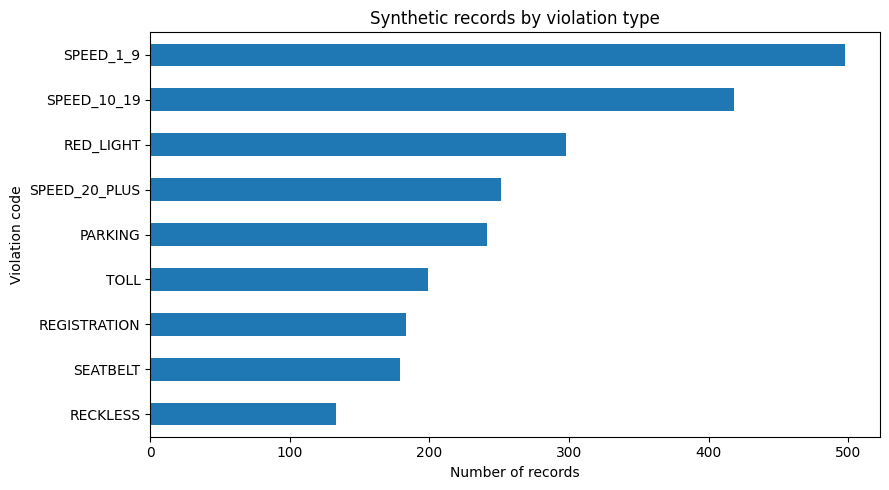

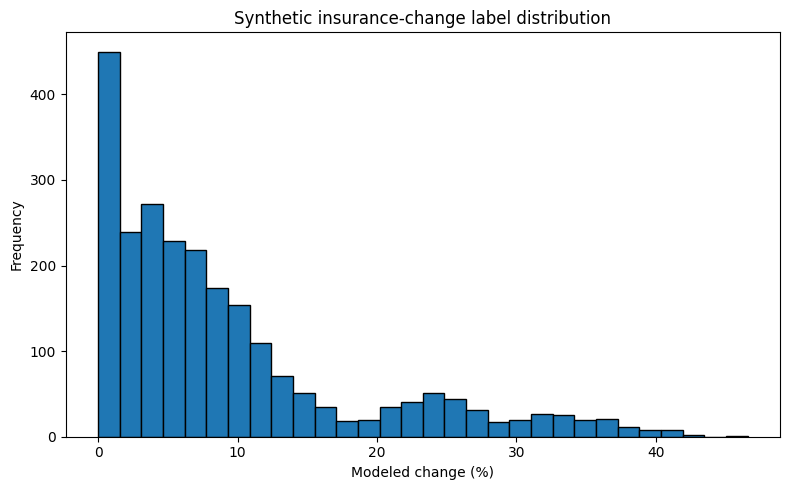

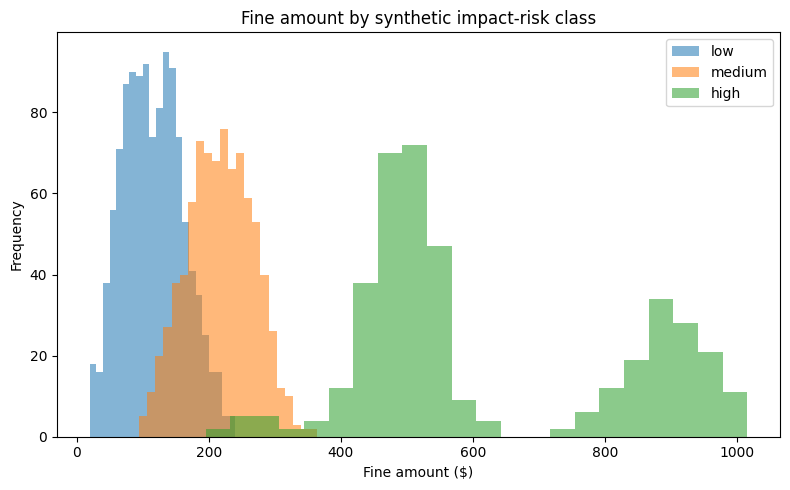

In [8]:
# Exploratory plots — each chart is separate for easy presentation.
fig, ax = plt.subplots(figsize=(9, 5))
data['violation_code'].value_counts().sort_values().plot(kind='barh', ax=ax)
ax.set_title('Synthetic records by violation type')
ax.set_xlabel('Number of records')
ax.set_ylabel('Violation code')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(data['insurance_change_pct'], bins=30, edgecolor='black')
ax.set_title('Synthetic insurance-change label distribution')
ax.set_xlabel('Modeled change (%)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for label in ['low', 'medium', 'high']:
    subset = data.loc[data['risk_level'] == label, 'fine_amount']
    ax.hist(subset, bins=22, alpha=0.55, label=label)
ax.set_title('Fine amount by synthetic impact-risk class')
ax.set_xlabel('Fine amount ($)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Train, calibration, test split

- **Training set:** fits model parameters.
- **Calibration set:** estimates prediction-error quantiles used in report ranges.
- **Test set:** provides an untouched final evaluation.

In [9]:
train_df, temp_df = train_test_split(
    data,
    test_size=0.40,
    random_state=SEED,
    stratify=data['risk_level']
)
cal_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df['risk_level']
)

print('Train:', train_df.shape, 'Calibration:', cal_df.shape, 'Test:', test_df.shape)

Train: (1440, 16) Calibration: (480, 16) Test: (480, 16)


## 6. Classical machine-learning pipelines

The feature transformer combines:

- TF-IDF features from the notice text;
- one-hot encoded jurisdiction, case type, and violation code; and
- stnadardized numeric values.

Separate models predict insuracne change, impact duration, license points, escalation risk, and overall impact class.

In [10]:
TEXT_COL = 'bill_text'
CAT_COLS = ['jurisdiction', 'case_type', 'violation_code']
NUM_COLS = ['fine_amount', 'days_to_due', 'prior_case_count', 'speed_over_mph', 'court_appearance_required']


def make_preprocessor(max_text_features=1400):
    return ColumnTransformer(
        transformers=[
            ('text', TfidfVectorizer(
                max_features=max_text_features,
                ngram_range=(1, 2),
                min_df=2,
                sublinear_tf=True
            ), TEXT_COL),
            ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_COLS),
            ('num', StandardScaler(with_mean=False), NUM_COLS),
        ],
        remainder='drop',
        sparse_threshold=0.3,
    )


def make_regression_pipeline(alpha=5.0):
    return Pipeline([
        ('preprocessor', make_preprocessor()),
        ('model', Ridge(alpha=alpha, solver='lsqr')),
    ])


def make_classification_pipeline(multiclass=False):
    return Pipeline([
        ('preprocessor', make_preprocessor()),
        ('model', LogisticRegression(
            max_iter=1500,
            class_weight='balanced',
            solver='lbfgs'
        )),
    ])

models = {
    'insurance': make_regression_pipeline(alpha=7.0),
    'duration': make_regression_pipeline(alpha=5.0),
    'points': make_regression_pipeline(alpha=5.0),
    'escalation': make_classification_pipeline(),
    'risk': make_classification_pipeline(multiclass=True),
}

targets = {
    'insurance': 'insurance_change_pct',
    'duration': 'impact_years',
    'points': 'license_points',
    'escalation': 'escalation_risk',
    'risk': 'risk_level',
}

for name, model in models.items():
    model.fit(train_df[INPUT_COLUMNS], train_df[targets[name]])
    print(f'Trained: {name}')

Trained: insurance
Trained: duration
Trained: points
Trained: escalation
Trained: risk


## 7. Test-set evaluation

In [11]:
def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'R2': r2_score(y_true, y_pred),
    }

metric_rows = []
for name in ['insurance', 'duration', 'points']:
    y_true = test_df[targets[name]].to_numpy()
    y_pred = models[name].predict(test_df[INPUT_COLUMNS])
    row = {'model': name, **regression_metrics(y_true, y_pred)}
    metric_rows.append(row)

regression_results = pd.DataFrame(metric_rows).set_index('model').round(3)
display(regression_results)

# Binary escalation model
esc_true = test_df['escalation_risk'].to_numpy()
esc_pred = models['escalation'].predict(test_df[INPUT_COLUMNS])
esc_prob = models['escalation'].predict_proba(test_df[INPUT_COLUMNS])[:, 1]
print('Escalation accuracy:', round(accuracy_score(esc_true, esc_pred), 3))
print('Escalation F1:', round(f1_score(esc_true, esc_pred), 3))
print('Escalation ROC-AUC:', round(roc_auc_score(esc_true, esc_prob), 3))

# Multiclass risk model
risk_true = test_df['risk_level'].to_numpy()
risk_pred = models['risk'].predict(test_df[INPUT_COLUMNS])
print('\nRisk-level accuracy:', round(accuracy_score(risk_true, risk_pred), 3))
print('Risk-level macro F1:', round(f1_score(risk_true, risk_pred, average='macro'), 3))
print('\nClassification report:')
print(classification_report(risk_true, risk_pred, digits=3))

,MAE,RMSE,R2
model,,,
insurance,1.861,2.299,0.938
duration,0.275,0.345,0.943
points,0.402,0.505,0.920


Escalation accuracy: 0.831
Escalation F1: 0.417
Escalation ROC-AUC: 0.853

Risk-level accuracy: 0.919
Risk-level macro F1: 0.923

Classification report:
              precision    recall  f1-score   support

        high      0.951     0.963     0.957        81
         low      0.928     0.936     0.932       233
      medium      0.890     0.873     0.881       166

    accuracy                          0.919       480
   macro avg      0.923     0.924     0.923       480
weighted avg      0.918     0.919     0.919       480



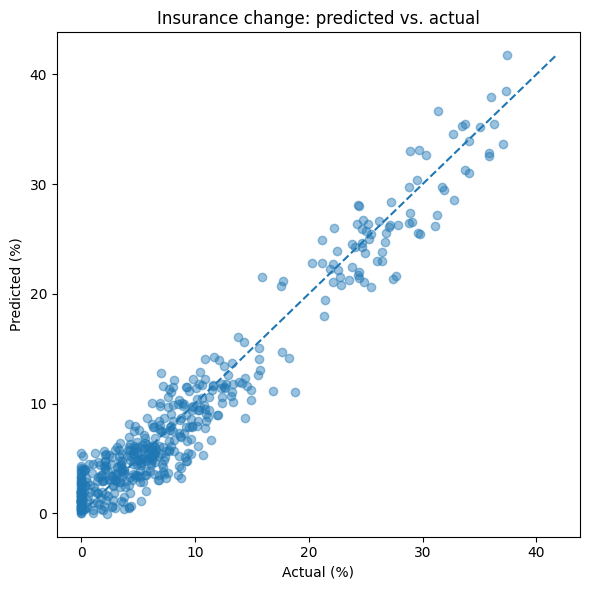

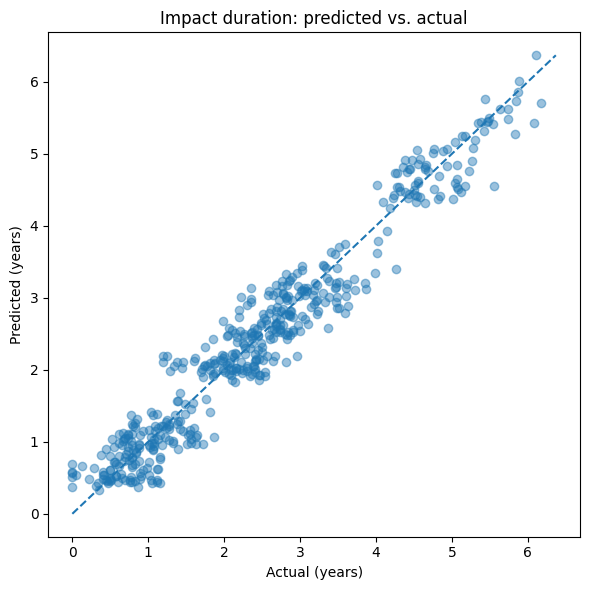

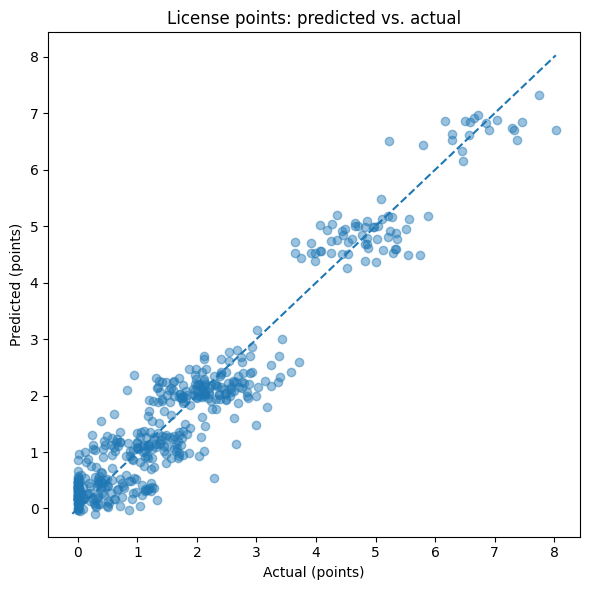

In [12]:
# Predicted vs. actual plots
for name, label, unit in [
    ('insurance', 'Insurance change', '%'),
    ('duration', 'Impact duration', 'years'),
    ('points', 'License points', 'points'),
]:
    y_true = test_df[targets[name]].to_numpy()
    y_pred = models[name].predict(test_df[INPUT_COLUMNS])
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, alpha=0.45)
    ax.plot([lo, hi], [lo, hi], linestyle='--')
    ax.set_title(f'{label}: predicted vs. actual')
    ax.set_xlabel(f'Actual ({unit})')
    ax.set_ylabel(f'Predicted ({unit})')
    plt.tight_layout()
    plt.show()

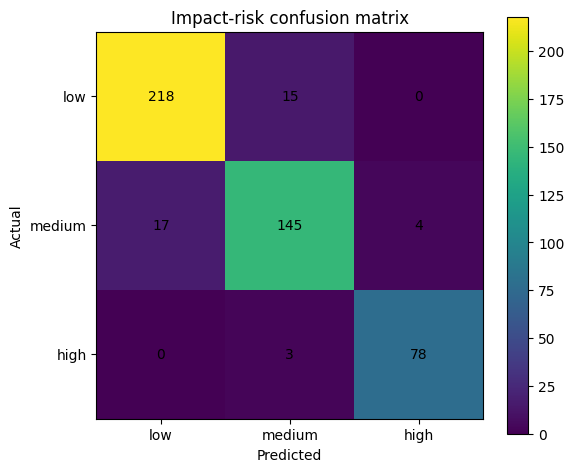

In [13]:
# Confusion matrix for the overall risk model
risk_labels = ['low', 'medium', 'high']
cm = confusion_matrix(risk_true, risk_pred, labels=risk_labels)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm)
ax.set_xticks(range(len(risk_labels)), risk_labels)
ax.set_yticks(range(len(risk_labels)), risk_labels)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Impact-risk confusion matrix')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### Calibration ranges

The notebook uses the calibration-set absolute residuals to form empirical 90% prediction ranges. This is a lightweight split-conformal approach: it does not guarantee legal correctness, but it is safer than showing a single overconfident number.

In [14]:
CALIBRATION_ALPHA = 0.10  # target approximately 90% empirical coverage
calibration_quantiles = {}
calibration_coverage = {}

for name in ['insurance', 'duration', 'points']:
    cal_true = cal_df[targets[name]].to_numpy()
    cal_pred = models[name].predict(cal_df[INPUT_COLUMNS])
    abs_residual = np.abs(cal_true - cal_pred)
    q = float(np.quantile(abs_residual, 1 - CALIBRATION_ALPHA, method='higher'))
    calibration_quantiles[name] = q

    test_true = test_df[targets[name]].to_numpy()
    test_pred = models[name].predict(test_df[INPUT_COLUMNS])
    covered = np.mean((test_true >= test_pred - q) & (test_true <= test_pred + q))
    calibration_coverage[name] = covered

calibration_table = pd.DataFrame({
    '90% residual half-width': calibration_quantiles,
    'test empirical coverage': calibration_coverage,
}).round(3)
display(calibration_table)

,90% residual half-width,test empirical coverage
insurance,3.682,0.888
duration,0.634,0.935
points,0.860,0.917


### Model interpretability

For the linear insuracne model, coefficient magnitude shows which transfored features most strongly move the synthetic estimate upward or downward. These are associations learned from the generated data, not causal legal rules.

,feature,coefficient
1250,cat__violation_code_REGISTRATION,-2.470
1253,cat__violation_code_SPEED_1_9,-1.306
140,text__16,-0.951
1251,cat__violation_code_SEATBELT,-0.926
856,text__for speed_10_19,-0.787
1199,text__speed_10_19 in,-0.787
968,text__is 20,0.673
913,text__is 143,0.693
205,text__20 mph,0.695
113,text__143,0.733


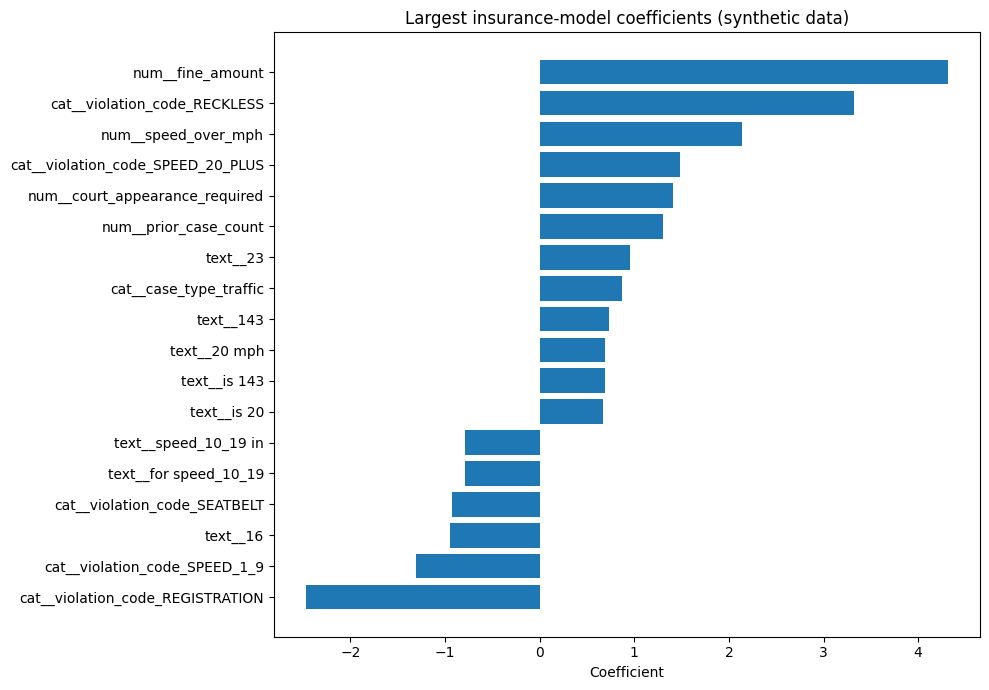

In [15]:
insurance_pipe = models['insurance']
feature_names = insurance_pipe.named_steps['preprocessor'].get_feature_names_out()
coefficients = insurance_pipe.named_steps['model'].coef_

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
top_coef = coef_df.nlargest(18, 'abs_coefficient').sort_values('coefficient')

display(top_coef[['feature', 'coefficient']].round(3))

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_coef['feature'], top_coef['coefficient'])
ax.set_title('Largest insurance-model coefficients (synthetic data)')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

## 8. PyTorch multi-task deep neural network

One shared neural representation feeds three task heads:

- regression: insurance change, duration, and license points;
- binary classification: nonpayment, escalation risk
- multiclass classification: low, medium, high impact.

In [16]:
# Fit one feature transformer for the DNN.
dnn_preprocessor = make_preprocessor(max_text_features=1000)
X_train_sparse = dnn_preprocessor.fit_transform(train_df[INPUT_COLUMNS])
X_cal_sparse = dnn_preprocessor.transform(cal_df[INPUT_COLUMNS])
X_test_sparse = dnn_preprocessor.transform(test_df[INPUT_COLUMNS])


def to_dense_float32(x):
    return x.toarray().astype(np.float32) if sp.issparse(x) else np.asarray(x, dtype=np.float32)

X_train_dnn = to_dense_float32(X_train_sparse)
X_cal_dnn = to_dense_float32(X_cal_sparse)
X_test_dnn = to_dense_float32(X_test_sparse)

REG_TARGETS = ['insurance_change_pct', 'impact_years', 'license_points']
RISK_TO_ID = {'low': 0, 'medium': 1, 'high': 2}
ID_TO_RISK = {v: k for k, v in RISK_TO_ID.items()}

reg_mean = train_df[REG_TARGETS].mean().to_numpy(dtype=np.float32)
reg_std = train_df[REG_TARGETS].std().replace(0, 1).to_numpy(dtype=np.float32)

def build_targets(df):
    y_reg = ((df[REG_TARGETS].to_numpy(dtype=np.float32) - reg_mean) / reg_std)
    y_esc = df['escalation_risk'].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_risk = df['risk_level'].map(RISK_TO_ID).to_numpy(dtype=np.int64)
    return y_reg, y_esc, y_risk

train_targets = build_targets(train_df)
cal_targets = build_targets(cal_df)
test_targets = build_targets(test_df)

print('DNN input dimension:', X_train_dnn.shape[1])

DNN input dimension: 1022


In [17]:
class MultiTaskImpactNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, 192),
            nn.ReLU(),
            nn.BatchNorm1d(192),
            nn.Dropout(0.25),
            nn.Linear(192, 96),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(96, 48),
            nn.ReLU(),
        )
        self.reg_head = nn.Linear(48, 3)
        self.escalation_head = nn.Linear(48, 1)
        self.risk_head = nn.Linear(48, 3)

    def forward(self, x):
        h = self.shared(x)
        return self.reg_head(h), self.escalation_head(h), self.risk_head(h)


def make_loader(X, targets, batch_size=96, shuffle=False):
    y_reg, y_esc, y_risk = targets
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y_reg, dtype=torch.float32),
        torch.tensor(y_esc, dtype=torch.float32),
        torch.tensor(y_risk, dtype=torch.long),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train_dnn, train_targets, shuffle=True)
cal_loader = make_loader(X_cal_dnn, cal_targets)

net = MultiTaskImpactNet(X_train_dnn.shape[1]).to(DEVICE)
optimizer = torch.optim.AdamW(net.parameters(), lr=1e-3, weight_decay=1e-4)
loss_reg = nn.MSELoss()
loss_binary = nn.BCEWithLogitsLoss()
loss_multi = nn.CrossEntropyLoss()

print(net)

MultiTaskImpactNet(
  (shared): Sequential(
    (0): Linear(in_features=1022, out_features=192, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=192, out_features=96, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=96, out_features=48, bias=True)
    (8): ReLU()
  )
  (reg_head): Linear(in_features=48, out_features=3, bias=True)
  (escalation_head): Linear(in_features=48, out_features=1, bias=True)
  (risk_head): Linear(in_features=48, out_features=3, bias=True)
)


In [18]:
def evaluate_dnn_loss(model, loader):
    model.eval()
    total = 0.0
    count = 0
    with torch.no_grad():
        for xb, yreg, yesc, yrisk in loader:
            xb, yreg, yesc, yrisk = xb.to(DEVICE), yreg.to(DEVICE), yesc.to(DEVICE), yrisk.to(DEVICE)
            preg, pesc, prisk = model(xb)
            loss = loss_reg(preg, yreg) + 0.35 * loss_binary(pesc, yesc) + 0.35 * loss_multi(prisk, yrisk)
            total += float(loss.item()) * len(xb)
            count += len(xb)
    return total / max(count, 1)

EPOCHS = 28
history = {'train_loss': [], 'cal_loss': []}
best_state = None
best_cal = float('inf')
patience = 6
no_improve = 0

for epoch in range(1, EPOCHS + 1):
    net.train()
    running = 0.0
    seen = 0
    for xb, yreg, yesc, yrisk in train_loader:
        xb, yreg, yesc, yrisk = xb.to(DEVICE), yreg.to(DEVICE), yesc.to(DEVICE), yrisk.to(DEVICE)
        optimizer.zero_grad()
        preg, pesc, prisk = net(xb)
        loss = loss_reg(preg, yreg) + 0.35 * loss_binary(pesc, yesc) + 0.35 * loss_multi(prisk, yrisk)
        loss.backward()
        optimizer.step()
        running += float(loss.item()) * len(xb)
        seen += len(xb)

    train_loss_value = running / seen
    cal_loss_value = evaluate_dnn_loss(net, cal_loader)
    history['train_loss'].append(train_loss_value)
    history['cal_loss'].append(cal_loss_value)

    if cal_loss_value < best_cal - 1e-4:
        best_cal = cal_loss_value
        best_state = {k: v.detach().cpu().clone() for k, v in net.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if epoch == 1 or epoch % 4 == 0:
        print(f'Epoch {epoch:02d} | train={train_loss_value:.4f} | calibration={cal_loss_value:.4f}')

    if no_improve >= patience:
        print(f'Early stopping at epoch {epoch}.')
        break

if best_state is not None:
    net.load_state_dict(best_state)
net.to(DEVICE)

Epoch 01 | train=1.2034 | calibration=1.3451
Epoch 04 | train=0.2737 | calibration=0.2637
Epoch 08 | train=0.2148 | calibration=0.2664
Early stopping at epoch 11.


MultiTaskImpactNet(
  (shared): Sequential(
    (0): Linear(in_features=1022, out_features=192, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=192, out_features=96, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=96, out_features=48, bias=True)
    (8): ReLU()
  )
  (reg_head): Linear(in_features=48, out_features=3, bias=True)
  (escalation_head): Linear(in_features=48, out_features=1, bias=True)
  (risk_head): Linear(in_features=48, out_features=3, bias=True)
)

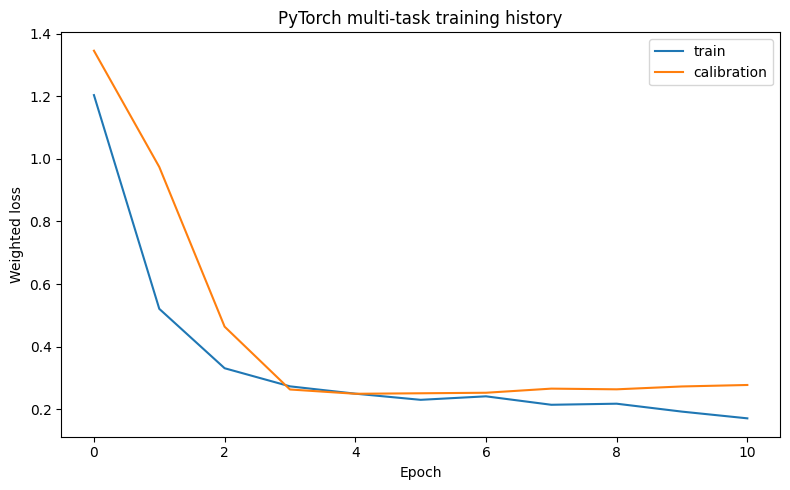

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history['train_loss'], label='train')
ax.plot(history['cal_loss'], label='calibration')
ax.set_title('PyTorch multi-task training history')
ax.set_xlabel('Epoch')
ax.set_ylabel('Weighted loss')
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
def dnn_predict(model, X):
    model.eval()
    with torch.no_grad():
        xb = torch.tensor(X, dtype=torch.float32, device=DEVICE)
        preg, pesc, prisk = model(xb)
        reg_scaled = preg.cpu().numpy()
        reg = reg_scaled * reg_std + reg_mean
        esc_prob = torch.sigmoid(pesc).cpu().numpy().ravel()
        risk_prob = torch.softmax(prisk, dim=1).cpu().numpy()
    return reg, esc_prob, risk_prob

reg_pred_dnn, esc_prob_dnn, risk_prob_dnn = dnn_predict(net, X_test_dnn)

rows = []
for j, target in enumerate(REG_TARGETS):
    metrics = regression_metrics(test_df[target].to_numpy(), reg_pred_dnn[:, j])
    rows.append({'target': target, **metrics})

dnn_regression_results = pd.DataFrame(rows).set_index('target').round(3)
display(dnn_regression_results)

esc_pred_dnn = (esc_prob_dnn >= 0.5).astype(int)
risk_pred_dnn = np.argmax(risk_prob_dnn, axis=1)
risk_true_id = test_df['risk_level'].map(RISK_TO_ID).to_numpy()

print('DNN escalation accuracy:', round(accuracy_score(esc_true, esc_pred_dnn), 3))
print('DNN escalation ROC-AUC:', round(roc_auc_score(esc_true, esc_prob_dnn), 3))
print('DNN risk accuracy:', round(accuracy_score(risk_true_id, risk_pred_dnn), 3))
print('DNN risk macro F1:', round(f1_score(risk_true_id, risk_pred_dnn, average='macro'), 3))

,MAE,RMSE,R2
target,,,
insurance_change_pct,1.959,2.406,0.932
impact_years,0.299,0.374,0.933
license_points,0.440,0.533,0.911


DNN escalation accuracy: 0.912
DNN escalation ROC-AUC: 0.852
DNN risk accuracy: 0.896
DNN risk macro F1: 0.901


## 9. Constrained reinforcement-learning demonstration



In [21]:
REPORT_STYLES = ['concise', 'detailed', 'action_first']
CONTEXTS = ['low', 'medium', 'high']
Q = pd.DataFrame(0.0, index=CONTEXTS, columns=REPORT_STYLES)
counts = pd.DataFrame(0, index=CONTEXTS, columns=REPORT_STYLES)

# Simulated preference probabilities for demonstration only.
preference = {
    'low': {'concise': 0.78, 'detailed': 0.45, 'action_first': 0.58},
    'medium': {'concise': 0.52, 'detailed': 0.72, 'action_first': 0.76},
    'high': {'concise': 0.35, 'detailed': 0.70, 'action_first': 0.88},
}

rng = np.random.default_rng(SEED)
epsilon = 0.15
alpha = 0.12

for _ in range(3500):
    context = rng.choice(CONTEXTS, p=[0.45, 0.38, 0.17])
    if rng.random() < epsilon:
        action = rng.choice(REPORT_STYLES)
    else:
        action = Q.loc[context].idxmax()
    reward = float(rng.random() < preference[context][action])
    Q.loc[context, action] += alpha * (reward - Q.loc[context, action])
    counts.loc[context, action] += 1

print('Learned report-style values (presentation only):')
display(Q.round(3))
print('Recommended style by context:')
display(Q.idxmax(axis=1).rename('recommended_style').to_frame())

Learned report-style values (presentation only):


,concise,detailed,action_first
low,0.787,0.409,0.293
medium,0.390,0.454,0.438
high,0.508,0.589,0.882


Recommended style by context:


,recommended_style
low,concise
medium,detailed
high,action_first


## 10. Document upload and text extration

Set `Run_upload_wdget = True` to upload a pdf, image, text file.

In [22]:
RUN_UPLOAD_WIDGET = False
uploaded_document_text = None
uploaded_filename = None


def extract_text_from_document(file_path):
    '''Extract text from TXT, PDF, or image. OCR is a fallback for scans.'''
    path = Path(file_path)
    suffix = path.suffix.lower()

    if suffix in {'.txt', '.md', '.csv'}:
        return path.read_text(encoding='utf-8', errors='ignore')

    if suffix == '.pdf':
        text_parts = []
        try:
            from pypdf import PdfReader
            reader = PdfReader(str(path))
            for page in reader.pages:
                text_parts.append(page.extract_text() or '')
        except Exception as exc:
            print('Direct PDF text extraction warning:', exc)

        text = '\n'.join(text_parts).strip()
        if len(text) >= 40:
            return text

        try:
            from pdf2image import convert_from_path
            import pytesseract
            images = convert_from_path(str(path), dpi=220)
            return '\n'.join(pytesseract.image_to_string(img) for img in images)
        except Exception as exc:
            raise RuntimeError(f'PDF appears scanned and OCR failed: {exc}')

    if suffix in {'.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp', '.webp'}:
        try:
            from PIL import Image
            import pytesseract
            return pytesseract.image_to_string(Image.open(path))
        except Exception as exc:
            raise RuntimeError(f'Image OCR failed: {exc}')

    raise ValueError(f'Unsupported file type: {suffix}')


if RUN_UPLOAD_WIDGET:
    if not IN_COLAB:
        raise RuntimeError('The upload widget is intended for Google Colab. Set a local file path instead.')
    from google.colab import files
    uploaded = files.upload()
    uploaded_filename = next(iter(uploaded))
    uploaded_document_text = extract_text_from_document(uploaded_filename)
    print(f'Extracted {len(uploaded_document_text)} characters from {uploaded_filename}.')
else:
    print('Upload widget skipped. The demo notice will be used.')

Upload widget skipped. The demo notice will be used.


## 11. Feature parser

The parser uses transparent regular expressions and keyword rules. A production system should replace these with jurisdiction-specific document templates and tested named-entity extraction.

In [23]:
DEMO_BILL_TEXT = '''
OFFICIAL CITATION / COURT NOTICE
Jurisdiction: Demo-MD
Violation: SPEED_10_19
The vehicle was recorded traveling 52 mph in a 35 mph zone, 17 mph above the limit.
Fine amount due: $225.00
Payment or response is due within 30 days.
Court appearance is not required unless the citation is contested.
'''.strip()


def infer_violation_code(text):
    upper = text.upper()
    direct_codes = ['RECKLESS', 'SPEED_20_PLUS', 'SPEED_10_19', 'SPEED_1_9',
                    'RED_LIGHT', 'REGISTRATION', 'SEATBELT', 'TOLL', 'PARKING']
    for code in direct_codes:
        if code in upper:
            return code

    if 'RECKLESS' in upper:
        return 'RECKLESS'
    if 'RED LIGHT' in upper or 'TRAFFIC SIGNAL' in upper:
        return 'RED_LIGHT'
    if 'SEAT BELT' in upper or 'SEATBELT' in upper:
        return 'SEATBELT'
    if 'REGISTRATION' in upper:
        return 'REGISTRATION'
    if 'TOLL' in upper:
        return 'TOLL'
    if 'PARKING' in upper:
        return 'PARKING'

    speed_over = infer_speed_over(text)
    if speed_over >= 20:
        return 'SPEED_20_PLUS'
    if speed_over >= 10:
        return 'SPEED_10_19'
    if speed_over > 0:
        return 'SPEED_1_9'
    return 'PARKING'


def infer_speed_over(text):
    patterns = [
        r'(\d{1,2})\s*mph\s*(?:over|above)',
        r'(\d{1,2})\s*miles?\s+per\s+hour\s*(?:over|above)',
        r'(\d{1,3})\s*mph\s+in\s+(?:a\s+)?(\d{1,3})\s*mph',
        r'traveling\s+(\d{1,3})\s*mph\s+in\s+(?:a\s+)?(\d{1,3})',
    ]
    for pattern in patterns:
        match = re.search(pattern, text, flags=re.IGNORECASE)
        if match:
            nums = [int(x) for x in match.groups()]
            return max(nums[0] - nums[1], 0) if len(nums) == 2 else nums[0]
    return 0


def parse_bill_text(text, defaults=None):
    defaults = defaults or {}
    clean = re.sub(r'\s+', ' ', text).strip()

    fine_match = re.search(r'(?:fine|amount|penalty)[^$\d]{0,25}\$?\s*([\d,]+(?:\.\d{1,2})?)', clean, re.IGNORECASE)
    due_match = re.search(r'(?:within|due in|respond in)\s+(\d{1,3})\s+days', clean, re.IGNORECASE)
    jur_match = re.search(r'Jurisdiction\s*[:\-]\s*([A-Za-z-]+)', clean, re.IGNORECASE)

    violation = infer_violation_code(clean)
    case_type_map = {
        'PARKING': 'parking', 'TOLL': 'civil',
        'SEATBELT': 'traffic', 'REGISTRATION': 'traffic', 'RED_LIGHT': 'traffic',
        'SPEED_1_9': 'traffic', 'SPEED_10_19': 'traffic', 'SPEED_20_PLUS': 'traffic', 'RECKLESS': 'traffic'
    }

    court_required = int(bool(re.search(r'court appearance\s+(?:is\s+)?required', clean, re.IGNORECASE)))
    if re.search(r'court appearance\s+(?:is\s+)?not required', clean, re.IGNORECASE):
        court_required = 0

    jurisdiction = jur_match.group(1) if jur_match else defaults.get('jurisdiction', 'Demo-MD')
    if not jurisdiction.startswith('Demo-'):
        # The trained notebook contains only fictional jurisdiction categories.
        jurisdiction = defaults.get('jurisdiction', 'Demo-MD')

    record = {
        'bill_text': clean,
        'jurisdiction': jurisdiction,
        'case_type': case_type_map.get(violation, defaults.get('case_type', 'traffic')),
        'violation_code': violation,
        'fine_amount': float(fine_match.group(1).replace(',', '')) if fine_match else float(defaults.get('fine_amount', 150.0)),
        'days_to_due': int(due_match.group(1)) if due_match else int(defaults.get('days_to_due', 30)),
        'prior_case_count': int(defaults.get('prior_case_count', 0)),
        'speed_over_mph': int(infer_speed_over(clean)),
        'court_appearance_required': court_required,
    }
    return record


source_text = uploaded_document_text if uploaded_document_text else DEMO_BILL_TEXT
parsed_case = parse_bill_text(source_text, defaults={'prior_case_count': 0, 'jurisdiction': 'Demo-MD'})
parsed_case_df = pd.DataFrame([parsed_case])

display(Markdown('### Extracted / supplied text'))
display(Markdown('```text\n' + source_text[:3000] + '\n```'))
display(Markdown('### Parsed model inputs'))
display(parsed_case_df.T.rename(columns={0: 'value'}))

### Extracted / supplied text

```text
OFFICIAL CITATION / COURT NOTICE
Jurisdiction: Demo-MD
Violation: SPEED_10_19
The vehicle was recorded traveling 52 mph in a 35 mph zone, 17 mph above the limit.
Fine amount due: $225.00
Payment or response is due within 30 days.
Court appearance is not required unless the citation is contested.
```

### Parsed model inputs

,value
bill_text,OFFICIAL CITATION / COURT NOTICE Jurisdiction:...
jurisdiction,Demo-MD
case_type,traffic
violation_code,SPEED_10_19
fine_amount,225.0
days_to_due,30
prior_case_count,0
speed_over_mph,17
court_appearance_required,0


## 12. Ensemble prediction and calibrated report

The report averages the classical and neural-network regression estimates, then applied classical-model calibration. It also reports uncertainty and separates:

- Modeled estimates learned from data.

- document facts extracted from the nocie

- unmodeled legal facts requireing an officla source and professional review

In [24]:
@dataclass
class ImpactPrediction:
    insurance_mid_pct: float
    insurance_low_pct: float
    insurance_high_pct: float
    duration_mid_years: float
    duration_low_years: float
    duration_high_years: float
    license_points_mid: float
    license_points_low: float
    license_points_high: float
    escalation_probability: float
    risk_level: str
    report_style: str
    model_scope: str = 'Synthetic educational prototype'


def predict_case(case_df):
    # Classical predictions
    ml_ins = float(models['insurance'].predict(case_df[INPUT_COLUMNS])[0])
    ml_dur = float(models['duration'].predict(case_df[INPUT_COLUMNS])[0])
    ml_pts = float(models['points'].predict(case_df[INPUT_COLUMNS])[0])
    ml_esc = float(models['escalation'].predict_proba(case_df[INPUT_COLUMNS])[0, 1])
    ml_risk_prob = models['risk'].predict_proba(case_df[INPUT_COLUMNS])[0]
    ml_risk_classes = list(models['risk'].named_steps['model'].classes_)

    # DNN predictions
    x_dnn = to_dense_float32(dnn_preprocessor.transform(case_df[INPUT_COLUMNS]))
    dnn_reg, dnn_esc, dnn_risk_prob = dnn_predict(net, x_dnn)

    # A simple equal-weight ensemble for demonstration.
    ins_mid = max(0.0, 0.5 * ml_ins + 0.5 * float(dnn_reg[0, 0]))
    dur_mid = max(0.0, 0.5 * ml_dur + 0.5 * float(dnn_reg[0, 1]))
    pts_mid = max(0.0, 0.5 * ml_pts + 0.5 * float(dnn_reg[0, 2]))
    esc_prob = float(np.clip(0.5 * ml_esc + 0.5 * dnn_esc[0], 0, 1))

    # Align classical risk probabilities to low/medium/high.
    ml_aligned = np.zeros(3, dtype=float)
    for cls, prob in zip(ml_risk_classes, ml_risk_prob):
        ml_aligned[RISK_TO_ID[cls]] = prob
    combined_risk = 0.5 * ml_aligned + 0.5 * dnn_risk_prob[0]
    risk_level = ID_TO_RISK[int(np.argmax(combined_risk))]

    qi = calibration_quantiles['insurance']
    qd = calibration_quantiles['duration']
    qp = calibration_quantiles['points']

    style = Q.loc[risk_level].idxmax()
    return ImpactPrediction(
        insurance_mid_pct=ins_mid,
        insurance_low_pct=max(0.0, ins_mid - qi),
        insurance_high_pct=max(0.0, ins_mid + qi),
        duration_mid_years=dur_mid,
        duration_low_years=max(0.0, dur_mid - qd),
        duration_high_years=max(0.0, dur_mid + qd),
        license_points_mid=pts_mid,
        license_points_low=max(0.0, pts_mid - qp),
        license_points_high=max(0.0, pts_mid + qp),
        escalation_probability=esc_prob,
        risk_level=risk_level,
        report_style=style,
    )


prediction = predict_case(parsed_case_df)
asdict(prediction)

{'insurance_mid_pct': 9.790203305290369,
 'insurance_low_pct': 6.108523381526841,
 'insurance_high_pct': 13.471883229053898,
 'duration_mid_years': 2.8755288883621692,
 'duration_low_years': 2.241099468198734,
 'duration_high_years': 3.5099583085256043,
 'license_points_mid': 2.0326807154039406,
 'license_points_low': 1.173004766025421,
 'license_points_high': 2.89235666478246,
 'escalation_probability': 0.14463084936141968,
 'risk_level': 'medium',
 'report_style': 'detailed',
 'model_scope': 'Synthetic educational prototype'}

In [25]:
def money(x):
    return f'${x:,.2f}'


def make_impact_report(case, pred):
    risk_pct = 100 * pred.escalation_probability
    action_items = [
        'Verify the citation number, jurisdiction, due date, and listed response options on the original notice.',
        'Use the official court or motor-vehicle-agency source to confirm points, deadlines, and hearing rights.',
        'Ask the current insurer for a quote or written explanation; the model cannot know an insurer-specific surcharge.',
        'Do not ignore the payment or response deadline. Seek qualified legal help when contesting the notice or when a court appearance is required.',
        'Redact names, addresses, account numbers, barcodes, and other identifiers before using documents for model development.',
    ]

    direct_credit_note = (
        'The prototype does not predict a fixed direct credit-score deduction from this notice. '
        'A separate escalation probability is shown because unpaid obligations may be handled differently, '
        'including possible collection activity, depending on the jurisdiction and facts.'
    )

    report = f'''
# Prototype Court-Bill Impact Report

**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M')}
**Model scope:** {pred.model_scope}
**Suggested report presentation:** {pred.report_style.replace('_', ' ').title()}

## 1. Extracted notice facts

- Fictional model jurisdiction: **{case['jurisdiction']}**
- Case type: **{case['case_type']}**
- Parsed violation: **{case['violation_code']}**
- Listed fine: **{money(case['fine_amount'])}**
- Response window: **{case['days_to_due']} days**
- Speed above limit: **{case['speed_over_mph']} mph**
- Court appearance marked required: **{'Yes' if case['court_appearance_required'] else 'No / not detected'}**

## 2. Modeled consequence ranges

| Output | Ensemble estimate | Approximate calibrated range |
|---|---:|---:|
| Possible insurance premium change | {pred.insurance_mid_pct:.1f}% | {pred.insurance_low_pct:.1f}% to {pred.insurance_high_pct:.1f}% |
| Possible impact duration | {pred.duration_mid_years:.1f} years | {pred.duration_low_years:.1f} to {pred.duration_high_years:.1f} years |
| Possible license points | {pred.license_points_mid:.1f} | {pred.license_points_low:.1f} to {pred.license_points_high:.1f} |
| Nonpayment / escalation probability | {risk_pct:.1f}% | Classification probability, not a legal finding |
| Overall modeled impact category | **{pred.risk_level.upper()}** | Synthetic training categories |

## 3. Credit-report interpretation

{direct_credit_note}

## 4. Recommended verification steps

'''
    report += '\n'.join(f'{i+1}. {item}' for i, item in enumerate(action_items))
    report += '''

## 5. Limitations

- The model was trained on generated demonstration data, not official court records.
- Actual license points, insurance effects, deadlines, collections, and collateral consequences vary by jurisdiction, disposition, insurer, policy, and individual circumstances.
- OCR and rule-based parsing can misread documents; compare every extracted field with the original notice.
- The report is not a determination of guilt, legal liability, sentence, eligibility, or creditworthiness.
- A real deployment must include human review, data-use agreements, privacy controls, bias evaluation, audit logs, model/version documentation, and a process for correction and appeal.
'''
    return report


impact_report_md = make_impact_report(parsed_case, prediction)
display(Markdown(impact_report_md))


# Prototype Court-Bill Impact Report

**Generated:** 2026-09-04 00:40
**Model scope:** Synthetic educational prototype
**Suggested report presentation:** Detailed

## 1. Extracted notice facts

- Fictional model jurisdiction: **Demo-MD**
- Case type: **traffic**
- Parsed violation: **SPEED_10_19**
- Listed fine: **$225.00**
- Response window: **30 days**
- Speed above limit: **17 mph**
- Court appearance marked required: **No / not detected**

## 2. Modeled consequence ranges

| Output | Ensemble estimate | Approximate calibrated range |
|---|---:|---:|
| Possible insurance premium change | 9.8% | 6.1% to 13.5% |
| Possible impact duration | 2.9 years | 2.2 to 3.5 years |
| Possible license points | 2.0 | 1.2 to 2.9 |
| Nonpayment / escalation probability | 14.5% | Classification probability, not a legal finding |
| Overall modeled impact category | **MEDIUM** | Synthetic training categories |

## 3. Credit-report interpretation

The prototype does not predict a fixed direct credit-score deduction from this notice. A separate escalation probability is shown because unpaid obligations may be handled differently, including possible collection activity, depending on the jurisdiction and facts.

## 4. Recommended verification steps

1. Verify the citation number, jurisdiction, due date, and listed response options on the original notice.
2. Use the official court or motor-vehicle-agency source to confirm points, deadlines, and hearing rights.
3. Ask the current insurer for a quote or written explanation; the model cannot know an insurer-specific surcharge.
4. Do not ignore the payment or response deadline. Seek qualified legal help when contesting the notice or when a court appearance is required.
5. Redact names, addresses, account numbers, barcodes, and other identifiers before using documents for model development.

## 5. Limitations

- The model was trained on generated demonstration data, not official court records.
- Actual license points, insurance effects, deadlines, collections, and collateral consequences vary by jurisdiction, disposition, insurer, policy, and individual circumstances.
- OCR and rule-based parsing can misread documents; compare every extracted field with the original notice.
- The report is not a determination of guilt, legal liability, sentence, eligibility, or creditworthiness.
- A real deployment must include human review, data-use agreements, privacy controls, bias evaluation, audit logs, model/version documentation, and a process for correction and appeal.


In [26]:
# Save the generated report and structured prediction in the runtime.
report_stem = 'prototype_court_bill_impact_report'
Path(report_stem + '.md').write_text(impact_report_md, encoding='utf-8')
Path(report_stem + '.json').write_text(
    json.dumps({'parsed_case': parsed_case, 'prediction': asdict(prediction)}, indent=2),
    encoding='utf-8'
)
print('Saved:', report_stem + '.md', 'and', report_stem + '.json')

# Optional Colab downloads
DOWNLOAD_REPORTS = False
if DOWNLOAD_REPORTS and IN_COLAB:
    from google.colab import files
    files.download(report_stem + '.md')
    files.download(report_stem + '.json')

Saved: prototype_court_bill_impact_report.md and prototype_court_bill_impact_report.json


# 13. Save trained artifacts

The following cell creates one compressed model bundle in the current runtime. It contains the classical piplines, DNN preprocessor, calibration values, and metadata. The requested deliverable remins this single notebook, downloading the model bundle is optional after training.

In [27]:
artifact = {
    'classical_models': models,
    'dnn_preprocessor': dnn_preprocessor,
    'dnn_state_dict': {k: v.detach().cpu() for k, v in net.state_dict().items()},
    'dnn_input_dim': X_train_dnn.shape[1],
    'reg_mean': reg_mean,
    'reg_std': reg_std,
    'calibration_quantiles': calibration_quantiles,
    'risk_to_id': RISK_TO_ID,
    'report_style_q_table': Q,
    'input_columns': INPUT_COLUMNS,
    'metadata': {
        'student': 'Claire Yuan',
        'mentor': 'Dr. Qingyang Xiao',
        'seed': SEED,
        'synthetic_training_data': True,
        'created_utc': datetime.utcnow().isoformat() + 'Z',
    },
}

artifact_path = 'claire_yuan_court_bill_impact_models.joblib'
joblib.dump(artifact, artifact_path, compress=3)
print('Saved model bundle:', artifact_path)

DOWNLOAD_MODEL_BUNDLE = False
if DOWNLOAD_MODEL_BUNDLE and IN_COLAB:
    from google.colab import files
    files.download(artifact_path)

Saved model bundle: claire_yuan_court_bill_impact_models.joblib
